In [209]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [210]:
import sys
import torch, torch.nn as nn, torch.optim as optim
from pathlib import Path
import matplotlib.pyplot as plt
project_root = Path.cwd().resolve().parents[2]
sys.path.append(str(project_root))

from defs.vae.ae import *
from defs.vae.training_defs import *

In [211]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

spectra, fractions = load_spectral_data()
# train_loader, val_loader = get_dataloaders(spectra, fractions)
unbatched_data = get_dataloader_unbatched(spectra, fractions)
print(unbatched_data.batch_size)
print(unbatched_data.dataset[0][0].size() )

Device: cpu
1
torch.Size([210])


In [ ]:
convolution = ConvEncoder([unbatched_data.batch_size, 32], [32], c_d={'pad': 1})
criterion = nn.MSELoss()
optimizer = optim.Adam(convolution.parameters(), lr=1e-3)

print(convolution.encoder)
print(convolution.decoder)

n_epochs = 10

Sequential(
  (0): Conv1d(1, 32, kernel_size=(3,), stride=(1,), padding=(1,))
  (1): ReLU()
  (2): MaxPool1d(kernel_size=1, stride=1, padding=0, dilation=1, ceil_mode=False)
)
Sequential(
  (0): ConvTranspose1d(32, 1, kernel_size=(3,), stride=(1,), padding=(1,))
  (1): Sigmoid()
)


In [213]:

losses = []
for epoch in range(1, n_epochs+1):
    convolution.train()
    tot_loss = 0
    for xb, yb in unbatched_data:
        xb = xb.to(device)
        optimizer.zero_grad()
        loss_pred = criterion(convolution(xb), xb)
        loss_pred.backward()
        optimizer.step()

        tot_loss += float(loss_pred)

    losses.append(tot_loss / len(unbatched_data.dataset))

print(losses)

[0.00045714645134965813, 3.56375814865414e-05, 2.3938204702609508e-05, 1.800214649163903e-05, 1.3356733146513477e-05]


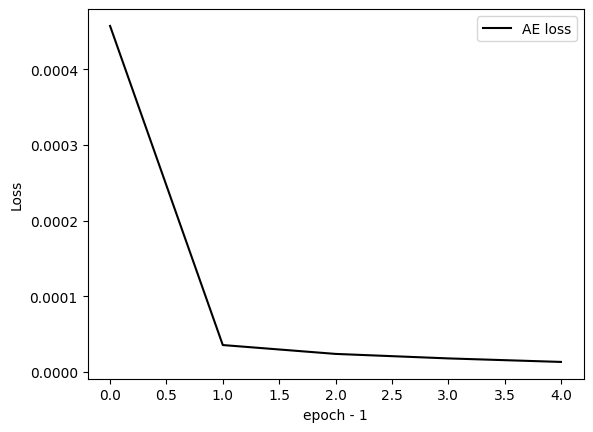

In [218]:
plt.plot(losses, color='black', label='AE loss')
plt.xlabel('epoch - 1'); plt.ylabel('Loss'); plt.legend()

In [215]:
#Thanks Ege


"""
# Testing the graph of the epsilon

# Create the test tensors
spec_tensor = torch.randn(5, 81).to(device)
time_tensor = torch.randn(5,).to(device)
ab_tensor = torch.randn(5, 3).to(device)

output = convolution()


# Create the graph:
from torchviz import make_dot
import graphviz
import os
os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"

make_dot(output, params=dict(convolution.named_parameters())).render("model_graph", format="png")
"""

<>:19: SyntaxWarning: invalid escape sequence '\P'
<>:19: SyntaxWarning: invalid escape sequence '\P'
/var/folders/pq/cnfsm69s0f721lh2sr1bvzpw0000gn/T/ipykernel_13126/2028828275.py:19: SyntaxWarning: invalid escape sequence '\P'
  os.environ["PATH"] += os.pathsep + r"C:\Program Files\Graphviz\bin"


'\n# Testing the graph of the epsilon\n\n# Create the test tensors\nspec_tensor = torch.randn(5, 81).to(device)\ntime_tensor = torch.randn(5,).to(device)\nab_tensor = torch.randn(5, 3).to(device)\n\noutput = convolution()\n\n\n# Create the graph:\nfrom torchviz import make_dot\nimport graphviz\nimport os\nos.environ["PATH"] += os.pathsep + r"C:\\Program Files\\Graphviz\x08in"\n\nmake_dot(output, params=dict(convolution.named_parameters())).render("model_graph", format="png")\n'